In [9]:
from sklearn.datasets import load_iris
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

import numpy as np
import matplotlib.pyplot as plt

iris = load_iris(as_frame=True)

X = iris.data.iloc[:,2:].to_numpy()
y = iris.target == 2

pipeline = Pipeline([
    ('sale',StandardScaler()),
    ('svc',LinearSVC(C=1,random_state=42))
])

pipeline.fit(X,y)

,steps,"[('sale', ...), ('svc', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001


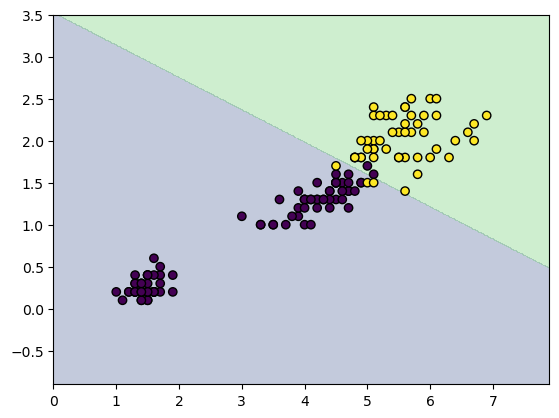

In [10]:
# 범위 설정
x0_min, x0_max =  X[:,0].min()-1, X[:,0].max()+1
x1_min, x1_max =  X[:,1].min()-1, X[:,1].max()+1

xx,yy = np.meshgrid(
    np.linspace(x0_min,x0_max,500),
    np.linspace(x1_min,x1_max,500)
)
grid = np.c_[xx.ravel(),yy.ravel()]

z = pipeline.predict(grid)
z = z.reshape(xx.shape)

plt.contourf(xx,yy,z, alpha=0.3)  # 결정영역
plt.scatter(X[:,0], X[:,1], c=y, edgecolors='k')
plt.show()

model --> lr --------------------------------------------------
              precision    recall  f1-score   support

           0       0.86      0.86      0.86        50
           1       0.86      0.86      0.86        50

    accuracy                           0.86       100
   macro avg       0.86      0.86      0.86       100
weighted avg       0.86      0.86      0.86       100

model --> sgd --------------------------------------------------
              precision    recall  f1-score   support

           0       0.84      0.92      0.88        50
           1       0.91      0.82      0.86        50

    accuracy                           0.87       100
   macro avg       0.87      0.87      0.87       100
weighted avg       0.87      0.87      0.87       100



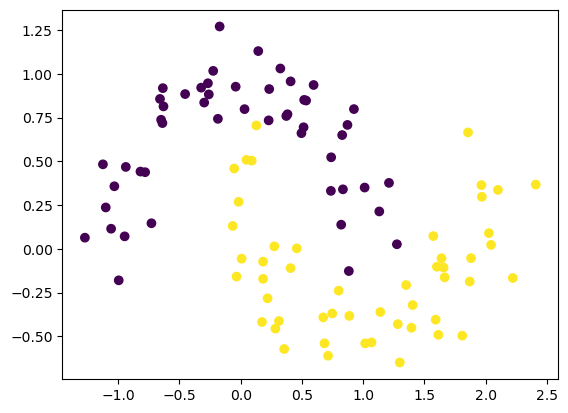

In [11]:
from sklearn.datasets import make_moons
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import classification_report
from sklearn.linear_model import SGDClassifier, LogisticRegression
from sklearn.pipeline import Pipeline
import matplotlib.pylab as plt
X,y = make_moons(n_samples=100, noise=0.15, random_state=42)
plt.scatter(X[:,0], X[:,1],c=y)

# 분류모델
from sklearn.linear_model import LogisticRegression

models = {'lr':LogisticRegression(random_state=42), 'sgd':SGDClassifier(random_state=42)}

for label,model in models.items():
    pipeline = Pipeline([
        ('scale', StandardScaler()),
        (label,model)
    ])
    pipeline.fit(X,y)
    predict = pipeline.predict(X)
    print(f'model --> {label}','-'*50)    
    print(classification_report(y,predict))

#파이프라인 만들어서 모델 학습, 예측값, f1-score

In [12]:
# svm 적용
from sklearn.svm import SVC
pipeline = Pipeline([
    ('scaler',StandardScaler()),
    #('svc',SVC(kernel='poly',degree=3,C=5,coef0=1))
    ('svc',SVC(kernel='rbf'))
])
pipeline.fit(X,y)
predict = pipeline.predict(X)
print(classification_report(y,predict))

              precision    recall  f1-score   support

           0       0.92      0.96      0.94        50
           1       0.96      0.92      0.94        50

    accuracy                           0.94       100
   macro avg       0.94      0.94      0.94       100
weighted avg       0.94      0.94      0.94       100



<Axes: xlabel='alcohol', ylabel='color_intensity'>

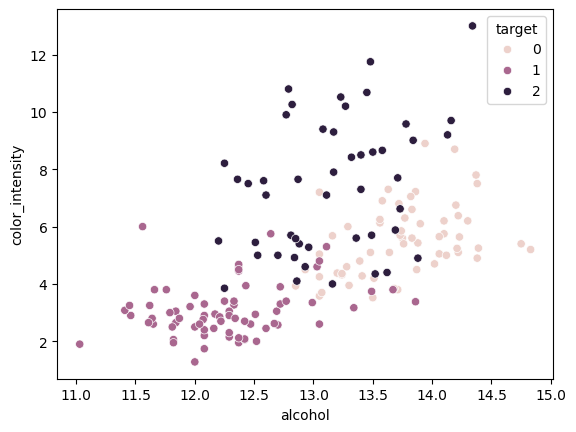

In [13]:
# 와인품질 분류
from sklearn.datasets import load_wine
# LinearSVC --> 선형
from sklearn.svm import SVC, LinearSVC
# 비선형, bnf 도 적용
wine = load_wine(as_frame=True)
import seaborn as sns
# sns.heatmap(data=wine.data.coref())
# dataframe coref
# sns.heatmap(data=wine.data.corr(), annot=True, cmap='coolwarm')
sns.scatterplot(x=wine.data['alcohol'], y=wine.data['color_intensity'], hue=wine.target)

In [14]:
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
X = wine.data.to_numpy()
y = wine.target
pipeline = Pipeline([
    ('scaler',StandardScaler()),
    ('svc',SVC(kernel='poly',degree=3,C=5,coef0=1))
])
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42,stratify=y)
pipeline.fit(X_train,y_train)
predict = pipeline.predict(X_test)
print(classification_report(y_test,predict))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       0.88      1.00      0.93        14
           2       1.00      0.80      0.89        10

    accuracy                           0.94        36
   macro avg       0.96      0.93      0.94        36
weighted avg       0.95      0.94      0.94        36



In [15]:
from sklearn.linear_model import LogisticRegression,SGDClassifier
X = wine.data.to_numpy()
y = wine.target
pipeline = Pipeline([
    ('scaler',StandardScaler()),
    ('model',LogisticRegression(random_state=42))
])
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42,stratify=y)
pipeline.fit(X_train,y_train)
predict = pipeline.predict(X_test)
print(classification_report(y_test,predict))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       0.93      1.00      0.97        14
           2       1.00      0.90      0.95        10

    accuracy                           0.97        36
   macro avg       0.98      0.97      0.97        36
weighted avg       0.97      0.97      0.97        36



In [16]:
from sklearn.linear_model import SGDClassifier
X = wine.data.to_numpy()
y = wine.target
pipeline = Pipeline([
    ('scaler',StandardScaler()),
    ('model',SGDClassifier(random_state=42))
])
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42, stratify=y)
pipeline.fit(X_train,y_train)
predict = pipeline.predict(X_test)
print(classification_report(y_test,predict))

              precision    recall  f1-score   support

           0       1.00      0.92      0.96        12
           1       0.93      1.00      0.97        14
           2       1.00      1.00      1.00        10

    accuracy                           0.97        36
   macro avg       0.98      0.97      0.97        36
weighted avg       0.97      0.97      0.97        36



In [17]:
from sklearn.datasets import load_iris
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

import numpy as np
import matplotlib.pyplot as plt

iris = load_iris(as_frame=True)

X = iris.data.iloc[:,2:].to_numpy()
y = iris.target == 2

pipeline = Pipeline([
    ('sale',StandardScaler()),
    ('svc',LinearSVC(C=1,random_state=42))
])

pipeline.fit(X,y)

,steps,"[('sale', ...), ('svc', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
